# Demo — Análisis de churn en un banco europeo
### Maestría en Fintech · ITBA · 2026

---

**Dataset:** 10.000 clientes de un banco europeo  
**Fuente:** [Kaggle — Churn for Bank Customers](https://www.kaggle.com/datasets/mathchi/churn-for-bank-customers)  
**Pregunta:** ¿Qué perfil de cliente tiene mayor probabilidad de irse del banco?

Este notebook es una demo completa del tipo de análisis que vas a poder hacer al final del curso.  
No hace falta entender el código todavía — enfocate en lo que muestran los gráficos y en las conclusiones.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías listas.')

Librerías listas.


---
## 1. Cargar el dataset

Los datos viven en la nube. Una línea alcanza para traerlos.

In [3]:
URL = 'https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv'

df = pd.read_csv(URL)

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head()

Filas:    10,000
Columnas: 13


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
## 2. ¿Qué tenemos?

Antes de cualquier análisis, entender el dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   Surname           10000 non-null  object 
 2   CreditScore       10000 non-null  int64  
 3   Geography         10000 non-null  object 
 4   Gender            10000 non-null  object 
 5   Age               10000 non-null  int64  
 6   Tenure            10000 non-null  int64  
 7   Balance           10000 non-null  float64
 8   Num Of Products   10000 non-null  int64  
 9   Has Credit Card   10000 non-null  int64  
 10  Is Active Member  10000 non-null  int64  
 11  Estimated Salary  10000 non-null  float64
 12  Churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


In [5]:
# Valores nulos por columna
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.any() else 'Ninguno — dataset limpio.')

Valores nulos por columna:
Ninguno — dataset limpio.


In [6]:
# Estadísticas descriptivas
df.describe().round(1)

,CustomerId,CreditScore,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,15690940.6,650.5,38.9,5.0,76485.9,1.5,0.7,0.5,100090.2,0.2
std,71936.2,96.7,10.5,2.9,62397.4,0.6,0.5,0.5,57510.5,0.4
min,15565701.0,350.0,18.0,0.0,0.0,1.0,0.0,0.0,11.6,0.0
25%,15628528.2,584.0,32.0,3.0,0.0,1.0,0.0,0.0,51002.1,0.0
50%,15690738.0,652.0,37.0,5.0,97198.5,1.0,1.0,1.0,100193.9,0.0
75%,15753233.8,718.0,44.0,7.0,127644.2,2.0,1.0,1.0,149388.2,0.0
max,15815690.0,850.0,92.0,10.0,250898.1,4.0,1.0,1.0,199992.5,1.0


In [7]:
# Tasa de churn global
tasa = df['Churn'].mean()
print(f'Clientes que se fueron: {df["Churn"].sum():,} de {len(df):,} ({tasa:.1%})')

Clientes que se fueron: 2,037 de 10,000 (20.4%)


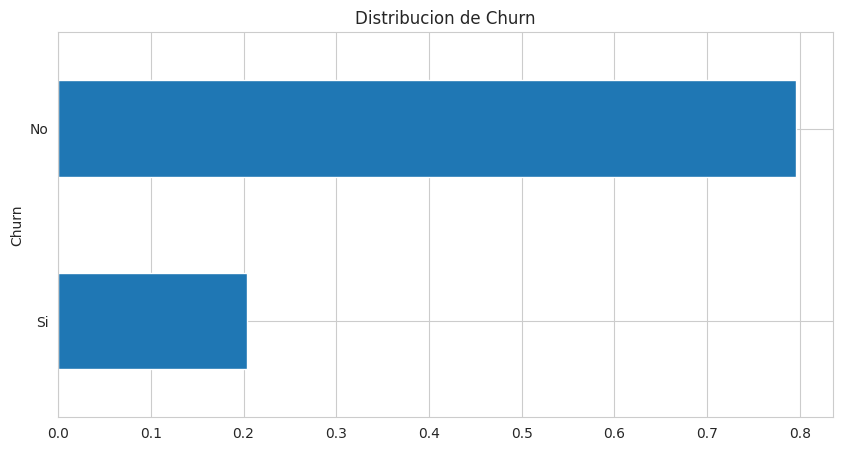

In [8]:
churn_counts = df['Churn'].value_counts(normalize=True, ascending=True)
churn_counts.index = churn_counts.index.map({0: 'No', 1: 'Si'})
churn_counts.plot(kind='barh', title='Distribucion de Churn');

---
## 3. ¿Cómo se distribuye la cartera?

Antes de buscar qué causa el churn, hay que entender a quiénes tenemos.

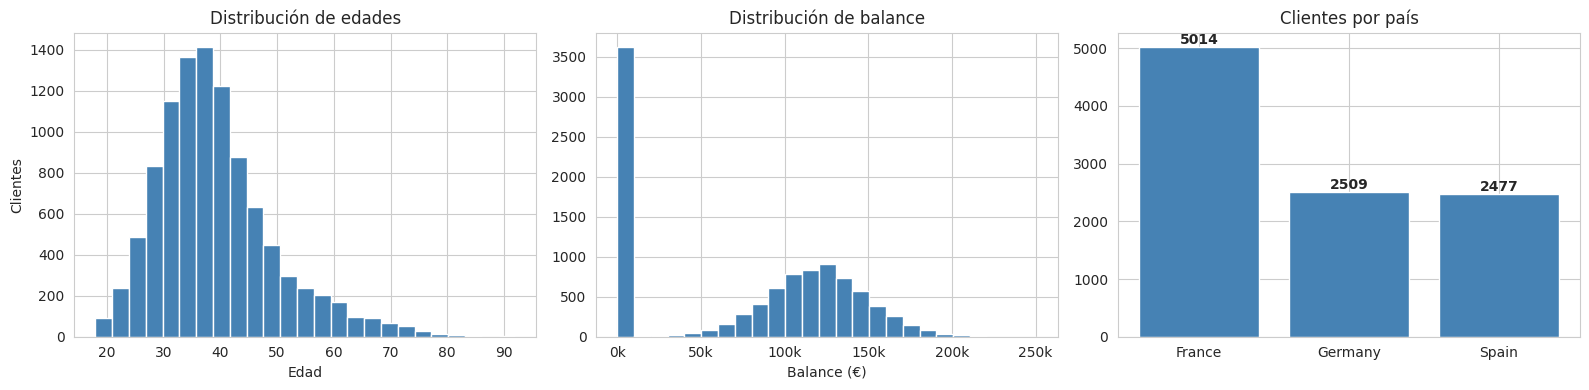

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución de edades
axes[0].hist(df['Age'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de edades')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Clientes')

# Distribución de balance
axes[1].hist(df['Balance'], bins=25, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de balance')
axes[1].set_xlabel('Balance (€)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Clientes por país
geo = df['Geography'].value_counts()
axes[2].bar(geo.index, geo.values, color='steelblue', edgecolor='white')
axes[2].set_title('Clientes por país')
for i, v in enumerate(geo.values):
    axes[2].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. ¿Quiénes se van?

Ahora sí: segmentar el churn por distintas variables para encontrar el perfil de riesgo.

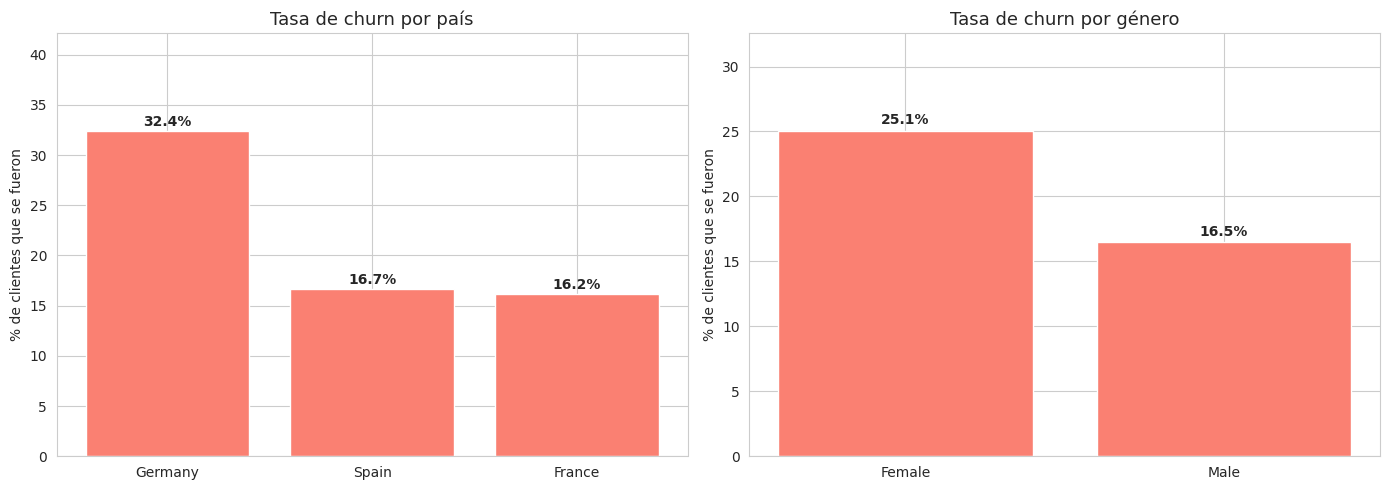

In [10]:
# Churn por país y por género
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por país
churn_geo = df.groupby('Geography')['Churn'].mean().sort_values(ascending=False)
bars = axes[0].bar(churn_geo.index, churn_geo.values * 100, color='salmon', edgecolor='white')
axes[0].set_title('Tasa de churn por país', fontsize=13)
axes[0].set_ylabel('% de clientes que se fueron')
axes[0].set_ylim(0, churn_geo.max() * 130)
for bar, val in zip(bars, churn_geo.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1%}', ha='center', fontweight='bold')

# Por género
churn_gen = df.groupby('Gender')['Churn'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(churn_gen.index, churn_gen.values * 100, color='salmon', edgecolor='white')
axes[1].set_title('Tasa de churn por género', fontsize=13)
axes[1].set_ylabel('% de clientes que se fueron')
axes[1].set_ylim(0, churn_gen.max() * 130)
for bar, val in zip(bars2, churn_gen.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

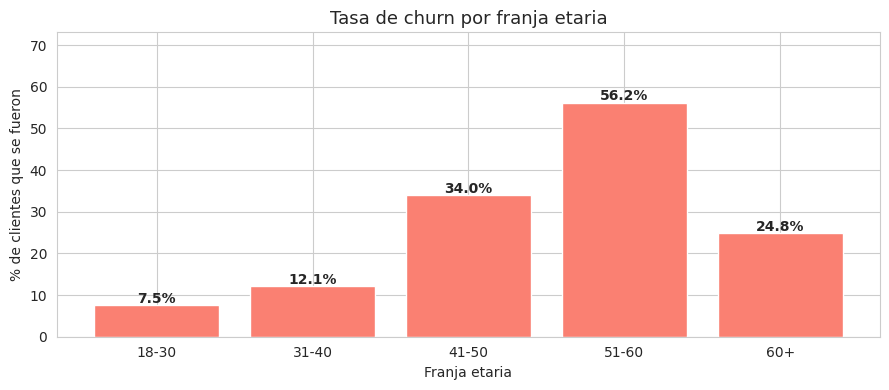

In [17]:
# Churn por franja etaria
df['franja_edad'] = pd.cut(df['Age'],
                           bins=[18, 30, 40, 50, 60, 100],
                           labels=['18-30', '31-40', '41-50', '51-60', '60+'])

churn_edad = df.groupby('franja_edad', observed=True)['Churn'].mean()

plt.figure(figsize=(9, 4))
bars = plt.bar(churn_edad.index.astype(str), churn_edad.values * 100,
               color='salmon', edgecolor='white')
plt.title('Tasa de churn por franja etaria', fontsize=13)
plt.ylabel('% de clientes que se fueron')
plt.xlabel('Franja etaria')
plt.ylim(0, churn_edad.max() * 130)
for bar, val in zip(bars, churn_edad.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Cuadro de doble entrada: Churn por país y franja etaria
pivot_table_churn = df.pivot_table(values='Churn', index='Geography', columns='franja_edad', aggfunc='mean')

# Formatear la tabla para mostrar porcentajes
formatted_pivot_table = pivot_table_churn.applymap(lambda x: f'{x:.1%}')

print("Tasa de Churn por País y Franja Etaria:")
formatted_pivot_table

Tasa de Churn por País y Franja Etaria:


/tmp/ipykernel_1630/479069151.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_churn = df.pivot_table(values='Churn', index='Geography', columns='franja_edad', aggfunc='mean')
/tmp/ipykernel_1630/479069151.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted_pivot_table = pivot_table_churn.applymap(lambda x: f'{x:.1%}')


franja_edad,18-30,31-40,41-50,51-60,60+
Geography,,,,,
France,4.9%,9.5%,28.1%,52.6%,19.9%
Germany,12.5%,20.9%,48.8%,69.5%,38.9%
Spain,8.5%,9.3%,27.3%,46.0%,20.8%


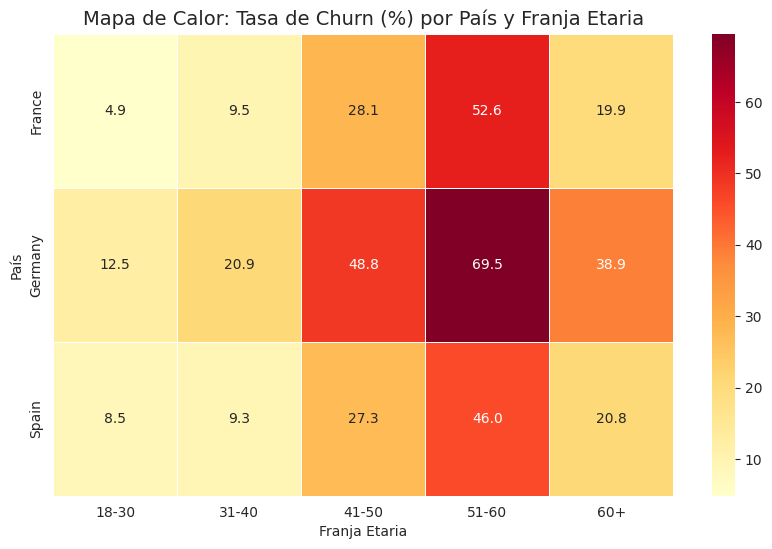

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table_churn * 100, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=.5)
plt.title('Mapa de Calor: Tasa de Churn (%) por País y Franja Etaria', fontsize=14)
plt.xlabel('Franja Etaria')
plt.ylabel('País')
plt.show()

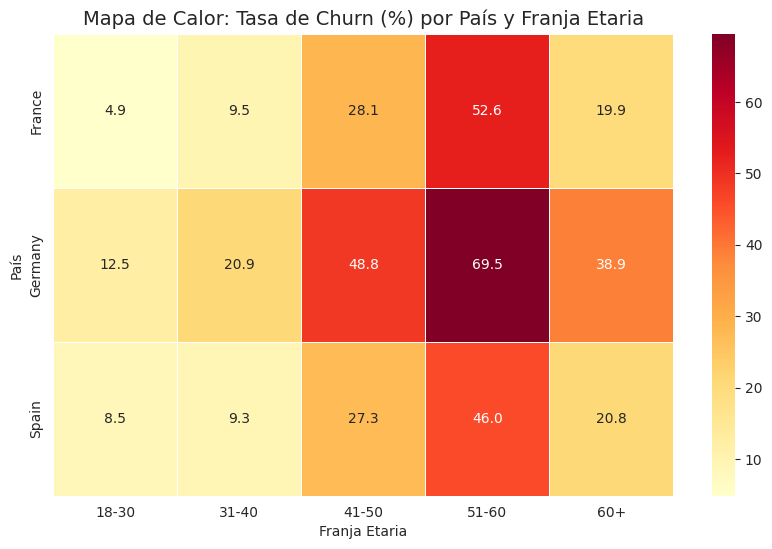

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table_churn * 100, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=.5)
plt.title('Mapa de Calor: Tasa de Churn (%) por País y Franja Etaria', fontsize=14)
plt.xlabel('Franja Etaria')
plt.ylabel('País')
plt.show()

In [25]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn,franja_edad
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50


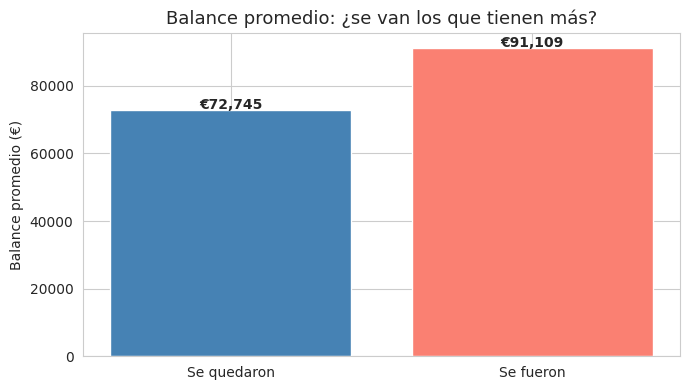

In [26]:
# Balance promedio: ¿quiénes se van vs quiénes se quedan?
balance_churn = df.groupby('Churn')['Balance'].mean()

labels = ['Se quedaron', 'Se fueron']
colors = ['steelblue', 'salmon']
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, balance_churn.values, color=colors, edgecolor='white')
plt.title('Balance promedio: ¿se van los que tienen más?', fontsize=13)
plt.ylabel('Balance promedio (€)')
for bar, val in zip(bars, balance_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'€{val:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

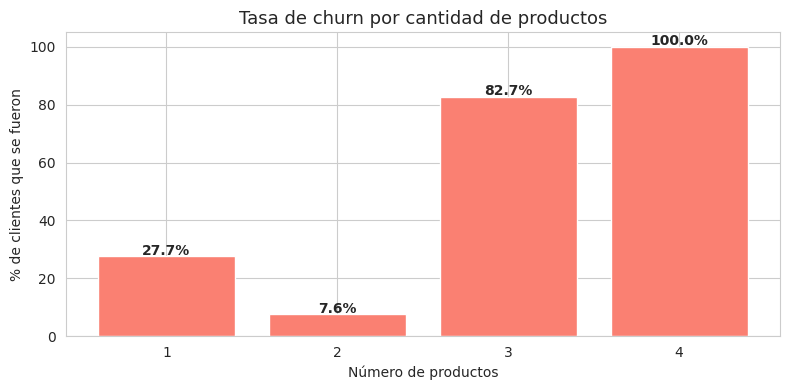

In [27]:
# Número de productos: ¿más productos = más fidelidad?
churn_prod = df.groupby('Num Of Products')['Churn'].mean()

plt.figure(figsize=(8, 4))
bars = plt.bar(churn_prod.index.astype(str), churn_prod.values * 100,
               color='salmon', edgecolor='white')
plt.title('Tasa de churn por cantidad de productos', fontsize=13)
plt.xlabel('Número de productos')
plt.ylabel('% de clientes que se fueron')
for bar, val in zip(bars, churn_prod.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Resumen: el perfil del cliente que se va

Construir una tabla resumen para comunicar los hallazgos.

In [28]:
resumen = df.groupby('Churn').agg(
    cantidad          = ('CustomerId', 'count'),
    edad_promedio     = ('Age', 'mean'),
    balance_promedio  = ('Balance', 'mean'),
    productos_prom    = ('Num Of Products', 'mean'),
    pct_activos       = ('Is Active Member', 'mean')
).round(1)

resumen.index = ['Se quedaron', 'Se fueron']
resumen['balance_promedio'] = resumen['balance_promedio'].apply(lambda x: f'€{x:,.0f}')
resumen['pct_activos']      = resumen['pct_activos'].apply(lambda x: f'{x:.0%}')
resumen

,cantidad,edad_promedio,balance_promedio,productos_prom,pct_activos
Se quedaron,7963,37.4,"€72,745",1.5,60%
Se fueron,2037,44.8,"€91,108",1.5,40%


---
## Conclusiones

Con este análisis podemos armar un mensaje concreto para el equipo de retención:

1. **El problema tiene escala:** 1 de cada 5 clientes se fue — una tasa que justifica una campaña de retención dedicada.

2. **La geografía importa:** Alemania tiene una tasa de churn significativamente mayor que Francia y España. Vale la pena entender qué está pasando en ese mercado.

3. **La edad es el factor más discriminante:** Los clientes de 41 a 60 años se van más que los jóvenes. Puede reflejar una propuesta de valor que no está llegando al segmento de mediana edad.

4. **Las mujeres se van más que los hombres** — una señal para revisar si el producto o la comunicación está teniendo un sesgo de género.

5. **Tener 3 o 4 productos es señal de alerta, no de fidelidad.** La hipótesis intuitiva (más productos = más fidelidad) no se cumple acá — requiere investigación adicional.

> *Esto es lo que hace un analista de datos: convertir números en preguntas que el negocio tiene que responder.*

Dimensiones del conjunto de entrenamiento X: (8000, 11)
Dimensiones del conjunto de prueba X: (2000, 11)
Dimensiones del conjunto de entrenamiento y: (8000,)
Dimensiones del conjunto de prueba y: (2000,)

Modelo de Regresión Logística entrenado.

Precisión (Accuracy) del modelo: 0.81

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


Características que más impactan en el Churn (ordenado por valor absoluto del coeficiente):
              Feature  Coefficient
6    Is Active Member       -1.029
8   Geography_Germany        0.818
1                 Age        0.736
10        Gender_Male       -0.525
3             Balance        0.161
0         CreditScore       -0.086
5     Has Credit Card  

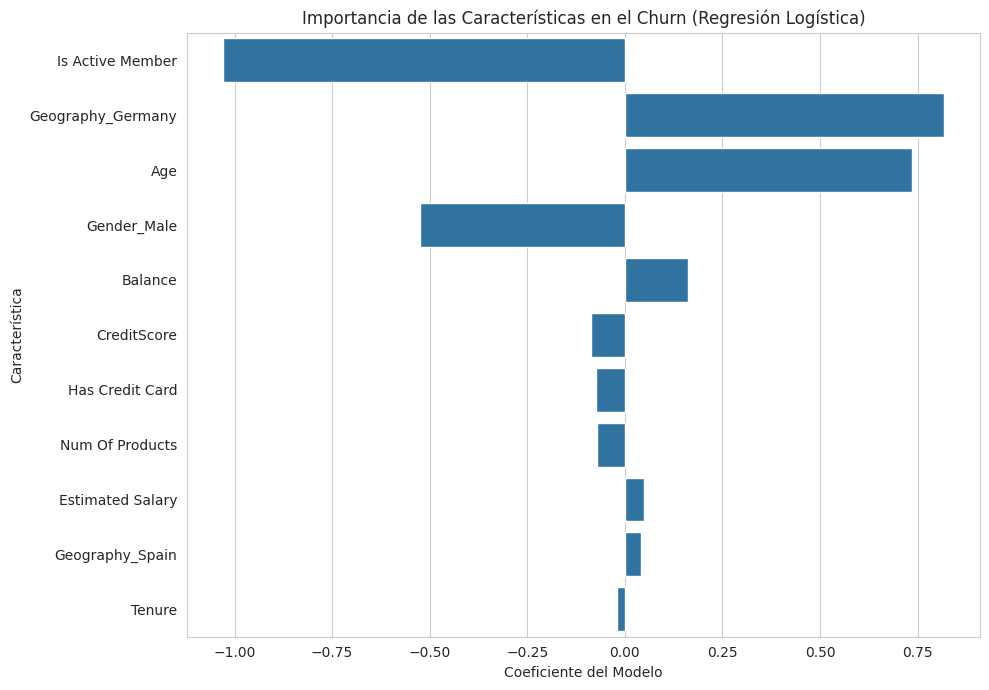

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Preparación de los datos
# Seleccionar características (X) y la variable objetivo (y)
# Excluir 'CustomerId', 'Surname' y 'franja_edad' (ya que 'Age' está incluida y es más granular)
features = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
            'Num Of Products', 'Has Credit Card', 'Is Active Member', 'Estimated Salary']
X = df[features]
y = df['Churn']

# Aplicar One-Hot Encoding a variables categóricas
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

# Identificar columnas numéricas para escalar
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'Num Of Products', 'Estimated Salary']

# Escalar características numéricas
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# 2. Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Dimensiones del conjunto de entrenamiento X: {X_train.shape}')
print(f'Dimensiones del conjunto de prueba X: {X_test.shape}')
print(f'Dimensiones del conjunto de entrenamiento y: {y_train.shape}')
print(f'Dimensiones del conjunto de prueba y: {y_test.shape}')

# 3. Entrenar el modelo de Regresión Logística
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' es bueno para datasets pequeños y para L1/L2
model.fit(X_train, y_train)

print('\nModelo de Regresión Logística entrenado.')

# 4. Evaluar el modelo
y_pred = model.predict(X_test)

print(f'\nPrecisión (Accuracy) del modelo: {accuracy_score(y_test, y_pred):.2f}')
print('\nReporte de Clasificación:')
print(classification_report(y_test, y_pred))

# 5. Analizar la importancia de las características
# Obtener los coeficientes del modelo
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

# Calcular el valor absoluto de los coeficientes para ordenar por magnitud de impacto
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print('\nCaracterísticas que más impactan en el Churn (ordenado por valor absoluto del coeficiente):')
print(feature_importance[['Feature', 'Coefficient']].round(3))

# Visualización de la importancia de las características
plt.figure(figsize=(10, 7))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Importancia de las Características en el Churn (Regresión Logística)')
plt.xlabel('Coeficiente del Modelo')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

### 6.2. Regresión Logística con balanceo de clases

Dado el desbalanceo en las clases de `Churn` (muchos más clientes se quedan que los que se van), el modelo inicial tuvo dificultades para identificar a los clientes que abandonan (bajo `recall` para la clase 1). Para corregir esto, reentrenaremos el modelo de Regresión Logística utilizando el parámetro `class_weight='balanced'`.

Modelo de Regresión Logística con balanceo de clases entrenado.

Precisión (Accuracy) del modelo balanceado: 0.71

Reporte de Clasificación del modelo balanceado:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000


Características que más impactan en el Churn (Modelo Balanceado):
              Feature  Coefficient
6    Is Active Member       -0.883
8   Geography_Germany        0.823
1                 Age        0.799
10        Gender_Male       -0.545
3             Balance        0.176
0         CreditScore       -0.087
5     Has Credit Card       -0.069
4     Num Of Products       -0.058
9     Geography_Spain        0.055
7    Estimated Salary        0.051
2              Tenure       -0.019


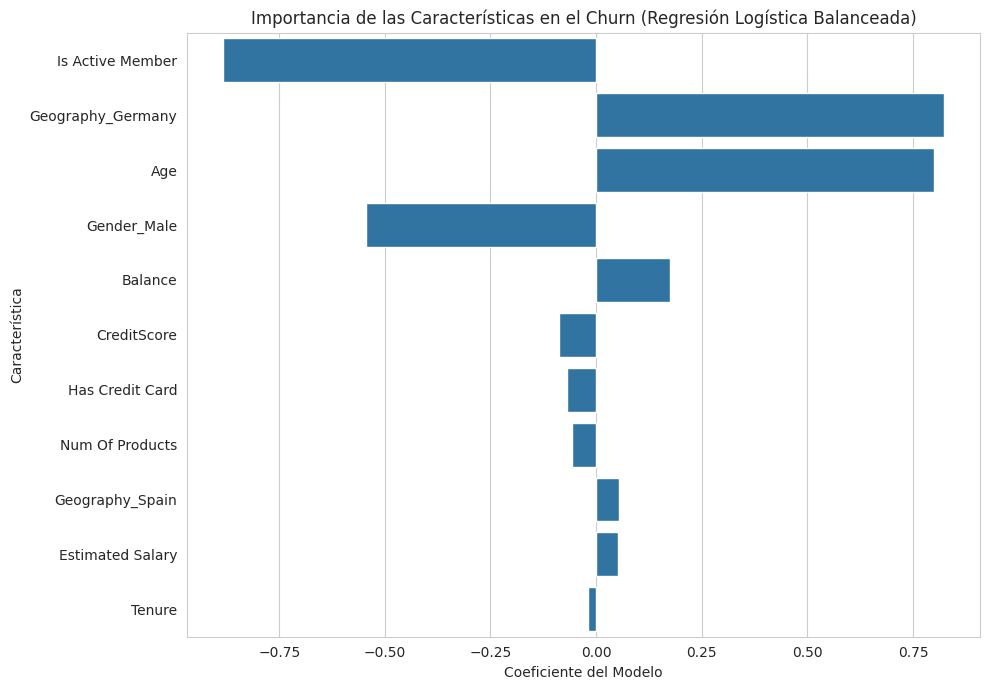

In [30]:
# Re-entrenar el modelo de Regresión Logística con class_weight='balanced'
model_balanced = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
model_balanced.fit(X_train, y_train)

print('Modelo de Regresión Logística con balanceo de clases entrenado.')

# Evaluar el modelo balanceado
y_pred_balanced = model_balanced.predict(X_test)

print(f'\nPrecisión (Accuracy) del modelo balanceado: {accuracy_score(y_test, y_pred_balanced):.2f}')
print('\nReporte de Clasificación del modelo balanceado:')
print(classification_report(y_test, y_pred_balanced))

# Analizar la importancia de las características con el modelo balanceado
feature_importance_balanced = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_balanced.coef_[0]
})

feature_importance_balanced['Abs_Coefficient'] = np.abs(feature_importance_balanced['Coefficient'])
feature_importance_balanced = feature_importance_balanced.sort_values(by='Abs_Coefficient', ascending=False)

print('\nCaracterísticas que más impactan en el Churn (Modelo Balanceado):')
print(feature_importance_balanced[['Feature', 'Coefficient']].round(3))

# Visualización de la importancia de las características del modelo balanceado
plt.figure(figsize=(10, 7))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_balanced)
plt.title('Importancia de las Características en el Churn (Regresión Logística Balanceada)')
plt.xlabel('Coeficiente del Modelo')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

### 6.3. Entrenamiento y Evaluación con Random Forest Classifier

Dado que la regresión logística puede tener limitaciones con relaciones no lineales, probaremos un modelo de Random Forest. Este modelo es un ensamble de árboles de decisión que suele capturar patrones más complejos en los datos.

Modelo Random Forest con balanceo de clases entrenado.

Precisión (Accuracy) del modelo Random Forest: 0.86

Reporte de Clasificación del modelo Random Forest:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000


Características que más impactan en el Churn (Random Forest):
              Feature  Importance
1                 Age       0.248
3             Balance       0.143
7    Estimated Salary       0.137
0         CreditScore       0.135
4     Num Of Products       0.133
2              Tenure       0.080
6    Is Active Member       0.037
8   Geography_Germany       0.034
10        Gender_Male       0.020
5     Has Credit Card       0.019
9     Geography_Spain       0.015


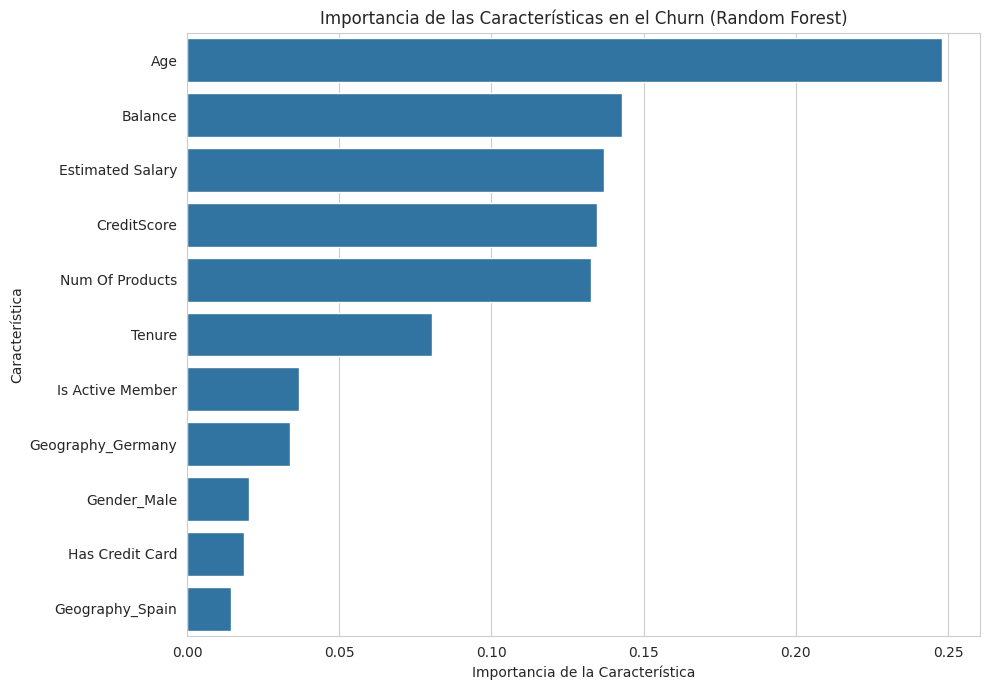

In [31]:
from sklearn.ensemble import RandomForestClassifier

# 1. Entrenar el modelo Random Forest
# Usamos class_weight='balanced' también para Random Forest, ya que el desbalanceo persiste.
# Puedes ajustar parámetros como n_estimators o max_depth para optimizar.
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
rf_model.fit(X_train, y_train)

print('Modelo Random Forest con balanceo de clases entrenado.')

# 2. Evaluar el modelo Random Forest
y_pred_rf = rf_model.predict(X_test)

print(f'\nPrecisión (Accuracy) del modelo Random Forest: {accuracy_score(y_test, y_pred_rf):.2f}')
print('\nReporte de Clasificación del modelo Random Forest:')
print(classification_report(y_test, y_pred_rf))

# 3. Analizar la importancia de las características con Random Forest
# Random Forest tiene un método integrado para la importancia de las características
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

print('\nCaracterísticas que más impactan en el Churn (Random Forest):')
print(feature_importance_rf.round(3))

# Visualización de la importancia de las características del modelo Random Forest
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf)
plt.title('Importancia de las Características en el Churn (Random Forest)')
plt.xlabel('Importancia de la Característica')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()